In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_excel("/content/Company stock prices.xlsx", sheet_name="in")
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
df.shape

(753, 7)

In [ ]:
df.sample(10)

,Date,Open,High,Low,Close,Adj Close,Volume
564,2023-01-17,331.079987,332.500000,323.600006,326.220001,326.220001,9247000
613,2023-03-28,326.059998,333.320007,321.279999,323.519989,323.519989,6489400
627,2023-04-18,335.000000,337.190002,330.500000,333.700012,333.700012,17944500
404,2022-05-26,186.490005,192.339996,183.089996,191.399994,191.399994,8049900
412,2022-06-08,197.949997,207.380005,197.639999,202.830002,202.830002,7244100
86,2021-02-23,525.000000,548.539978,518.280029,546.150024,546.150024,4136500
260,2021-10-29,673.059998,690.969971,671.239990,690.309998,690.309998,3825300
549,2022-12-22,298.089996,298.880005,290.809998,297.750000,297.750000,7856200
113,2021-04-01,529.929993,540.500000,527.030029,539.419983,539.419983,3938600
518,2022-11-08,259.920013,266.079987,256.880005,263.459991,263.459991,7683800


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       753 non-null    datetime64[ns]
 1   Open       753 non-null    float64       
 2   High       753 non-null    float64       
 3   Low        753 non-null    float64       
 4   Close      753 non-null    float64       
 5   Adj Close  753 non-null    float64       
 6   Volume     753 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 41.3 KB


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
print("\n--- Date range ---")
print("Start:", df["Date"].min())
print("End:", df["Date"].max())
print("Total trading days:", df.shape[0])


--- Date range ---
Start: 2020-10-19 00:00:00
End: 2023-10-16 00:00:00
Total trading days: 753


In [ ]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,753,753.000000,753.000000,753.000000,753.000000,753.000000,7.530000e+02
mean,2022-04-17 10:23:25.577689344,414.903107,421.117954,408.519270,414.796653,414.796653,7.060370e+06
min,2020-10-19 00:00:00,163.960007,172.059998,162.710007,166.369995,166.369995,1.144000e+06
25%,2021-07-20 00:00:00,311.570007,319.799988,308.850006,313.480011,313.480011,3.629200e+06
50%,2022-04-18 00:00:00,418.399994,425.260010,411.880005,416.029999,416.029999,5.277700e+06
75%,2023-01-17 00:00:00,519.900024,526.380005,513.789978,519.780029,519.780029,7.973300e+06
max,2023-10-16 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,1.333875e+08
std,NaN,135.039753,135.568500,134.016834,134.669664,134.669664,7.470407e+06


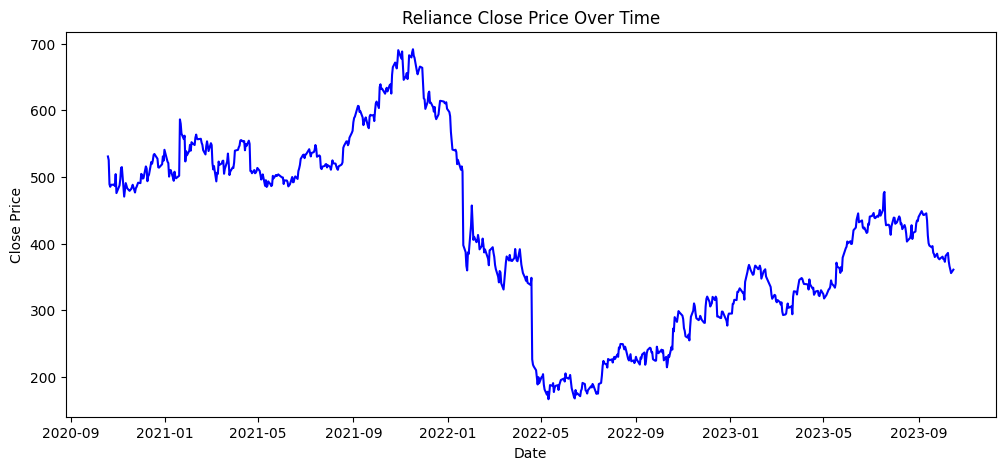

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Reliance Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

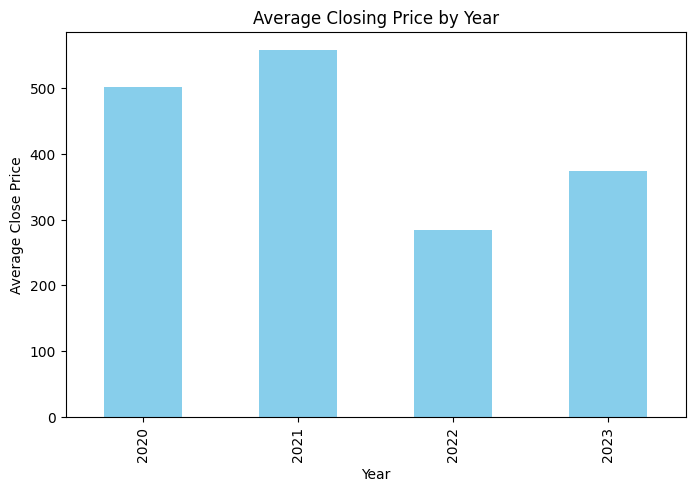

In [ ]:
df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(8,5))
yearly_avg.plot(kind='bar', color='skyblue')
plt.title('Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.show()

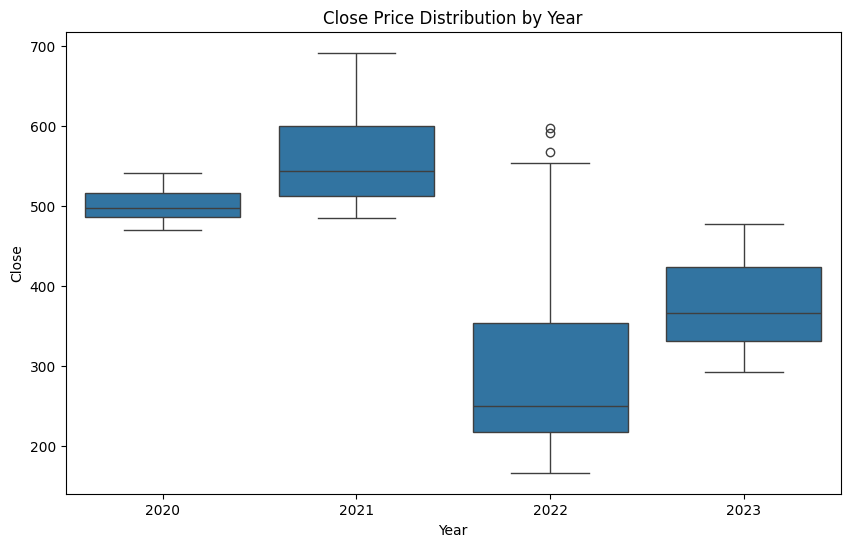

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Year', y='Close', data=df)
plt.title('Close Price Distribution by Year')
plt.show()

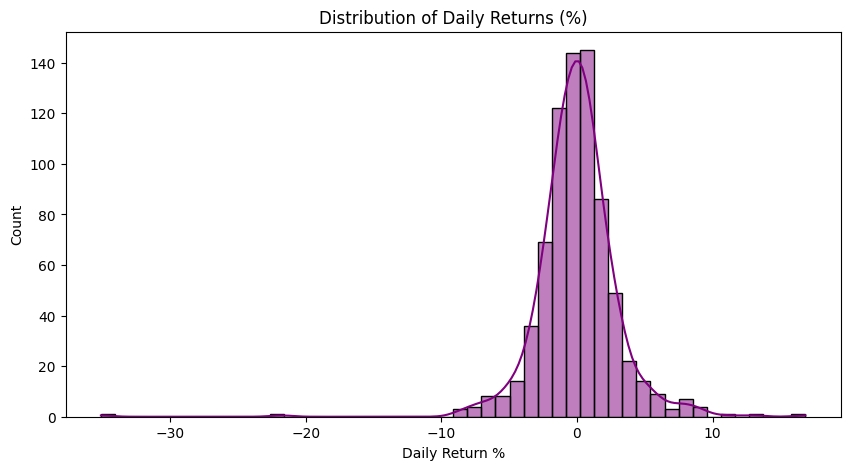

In [ ]:
df['Daily_Return_%'] = df['Close'].pct_change() * 100
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return_%'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Returns (%)')
plt.xlabel('Daily Return %')
plt.show()

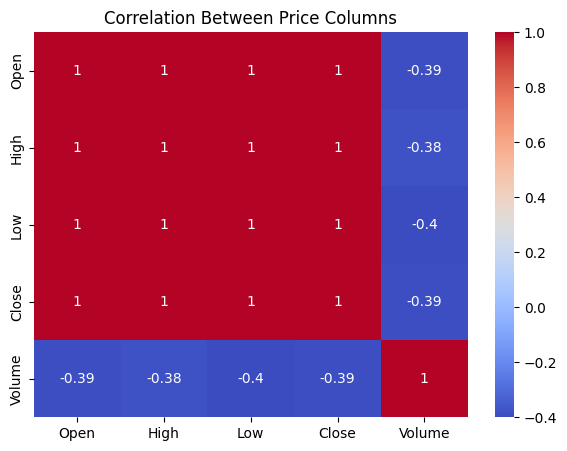

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Price Columns')
plt.show()

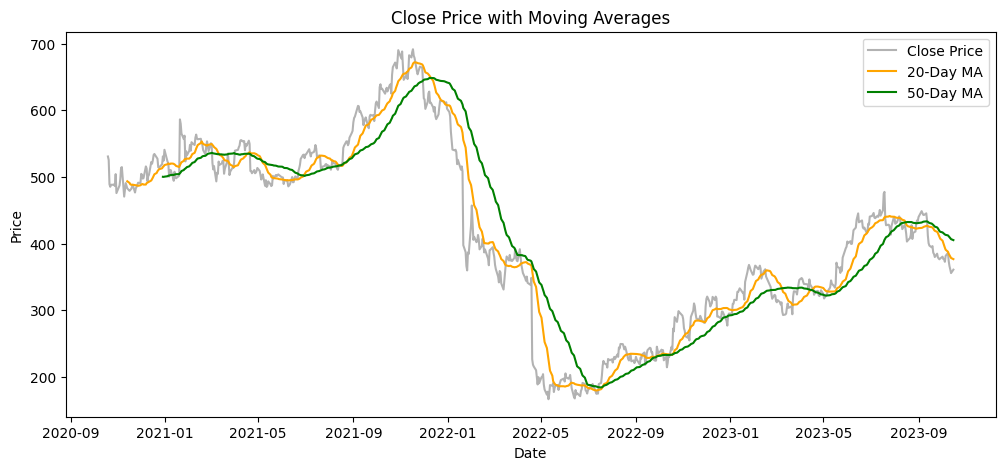

In [ ]:
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='grey', alpha=0.6)
plt.plot(df['Date'], df['MA_20'], label='20-Day MA', color='orange')
plt.plot(df['Date'], df['MA_50'], label='50-Day MA', color='green')
plt.title('Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

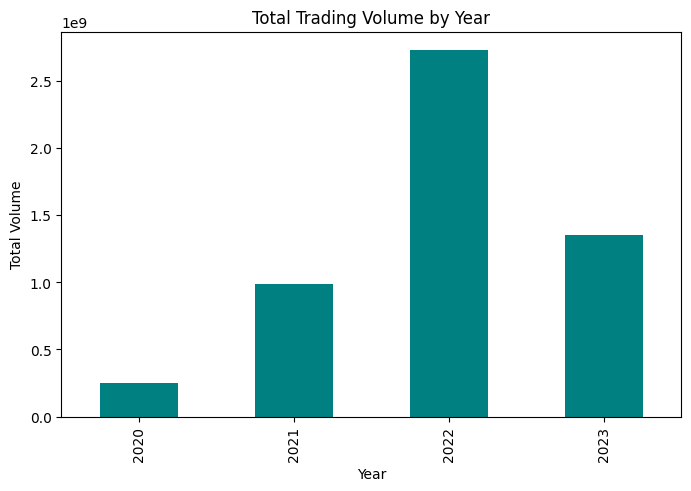

In [ ]:
yearly_volume = df.groupby('Year')['Volume'].sum()

plt.figure(figsize=(8,5))
yearly_volume.plot(kind='bar', color='teal')
plt.title('Total Trading Volume by Year')
plt.xlabel('Year')
plt.ylabel('Total Volume')
plt.show()

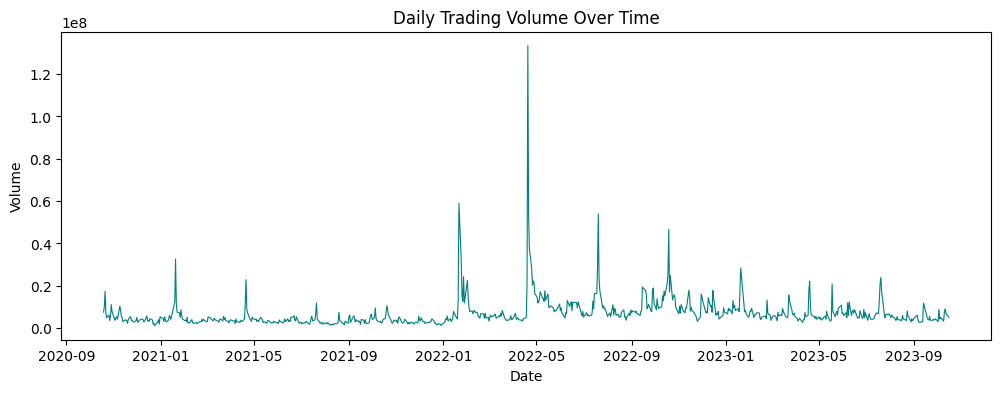

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Volume'], color='teal', linewidth=0.8)
plt.title('Daily Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [ ]:
biggest_drop = df.loc[df['Daily_Return_%'].idxmin()]
biggest_gain = df.loc[df['Daily_Return_%'].idxmax()]
print("Biggest single-day drop:\n", biggest_drop)
print("\nBiggest single-day gain:\n", biggest_gain)

Biggest single-day drop:
 Date              2022-04-20 00:00:00
Open                       245.199997
High                       248.699997
Low                        212.509995
Close                      226.190002
Adj Close                  226.190002
Volume                      133387500
Year                             2022
Daily_Return_%             -35.116603
MA_20                      358.912999
MA_50                        369.5658
Name: 378, dtype: object

Biggest single-day gain:
 Date              2021-01-20 00:00:00
Open                       565.419983
High                       593.289978
Low                        556.859985
Close                      586.340027
Adj Close                  586.340027
Volume                       32637500
Year                             2021
Daily_Return_%              16.854344
MA_20                      517.576497
MA_50                      505.657599
Name: 63, dtype: object


In [ ]:
split_date = pd.Timestamp('2022-04-20')
price_cols = ['Open','High','Low','Close']
df.loc[df['Date'] < split_date, price_cols] = df.loc[df['Date'] < split_date, price_cols] / 2
df.loc[df['Date'] < split_date, 'Volume'] = df.loc[df['Date'] < split_date, 'Volume'] * 2

In [ ]:
for lag in [1, 2, 3, 5, 10]:
    df[f'Close_lag_{lag}'] = df['Close'].shift(lag)

In [ ]:
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_21'] = df['Close'].rolling(21).mean()
df['STD_7'] = df['Close'].rolling(7).std()
df['Volume_MA_7'] = df['Volume'].rolling(7).mean()

In [ ]:
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

In [ ]:
df_model = df.dropna().reset_index(drop=True)
print(df_model.shape)

(704, 23)


In [ ]:
test_size = 30
train = df_model.iloc[:-test_size]
test = df_model.iloc[-test_size:]

print("Train period:", train['Date'].min(), "to", train['Date'].max())
print("Test period:", test['Date'].min(), "to", test['Date'].max())

Train period: 2020-12-29 00:00:00 to 2023-09-01 00:00:00
Test period: 2023-09-05 00:00:00 to 2023-10-16 00:00:00


In [ ]:
feature_cols = ['Close_lag_1','Close_lag_2','Close_lag_3','Close_lag_5','Close_lag_10','MA_7','MA_21','STD_7','Volume_MA_7','DayOfWeek','Month','Quarter']

X_train, y_train = train[feature_cols], train['Close']
X_test, y_test = test[feature_cols], test['Close']

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name}: RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape:.2f}%")
    return rmse, mae, mape

In [ ]:
naive_pred = test['Close_lag_1']  # "tomorrow = today's price"
evaluate(y_test, naive_pred, "Naive Baseline")

Naive Baseline: RMSE=7.05  MAE=5.35  MAPE=1.36%


(np.float64(7.052718850451747),
 5.353334533333337,
 np.float64(1.3616064919614366))

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

evaluate(y_test, lr_pred, "Linear Regression")

Linear Regression: RMSE=5.26  MAE=4.01  MAPE=1.03%


(np.float64(5.2589810122697305),
 4.008096008752977,
 np.float64(1.025283834775311))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

evaluate(y_test, rf_pred, "Random Forest")

Random Forest: RMSE=19.65  MAE=17.61  MAPE=4.63%


(np.float64(19.64704136146388),
 17.610805002456512,
 np.float64(4.631217585430826))

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Close'], order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=test_size)

evaluate(y_test.values, arima_pred.values, "ARIMA")

ARIMA: RMSE=52.87  MAE=47.29  MAPE=12.48%


(np.float64(52.868686349871474),
 47.286668281614574,
 np.float64(12.479762741790324))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

evaluate(y_test, gb_pred, "Gradient Boosting")

Gradient Boosting: RMSE=19.40  MAE=17.76  MAPE=4.65%


(np.float64(19.395782613025776),
 17.76010952779463,
 np.float64(4.650645112290238))

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

evaluate(y_test, xgb_pred, "XGBoost")

XGBoost: RMSE=12.61  MAE=10.54  MAPE=2.73%


(np.float64(12.612575356644642),
 10.539560014192713,
 np.float64(2.725750173215811))

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

evaluate(y_test, svr_pred, "SVR")

SVR: RMSE=10.71  MAE=8.70  MAPE=2.15%


(np.float64(10.705729883913682),
 8.700372448489615,
 np.float64(2.1549795779837133))

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Scale close price to 0-1 range (LSTMs train better on small, scaled numbers)
scaler_lstm = MinMaxScaler()
scaled_close = scaler_lstm.fit_transform(df_model[['Close']])

# Build sequences: use past 10 days to predict the next day
seq_len = 10
X_seq, y_seq = [], []
for i in range(seq_len, len(scaled_close)):
    X_seq.append(scaled_close[i-seq_len:i, 0])
    y_seq.append(scaled_close[i, 0])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Same chronological split as before
X_seq_train, X_seq_test = X_seq[:-test_size], X_seq[-test_size:]
y_seq_train, y_seq_test = y_seq[:-test_size], y_seq[-test_size:]

lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_seq_train, y_seq_train, epochs=20, batch_size=16, verbose=1)

lstm_pred_scaled = lstm.predict(X_seq_test)
lstm_pred = scaler_lstm.inverse_transform(lstm_pred_scaled).flatten()
y_seq_test_actual = scaler_lstm.inverse_transform(y_seq_test.reshape(-1,1)).flatten()

evaluate(y_seq_test_actual, lstm_pred, "LSTM")

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0635
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016
Epoch 9/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 10/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016
Epoch 11/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 12/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 13/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015
Epoch 14/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 15/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016
Epoch 16/20
42/42 

(np.float64(9.550204324044858),
 6.732995636263024,
 np.float64(1.6967260835531666))

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test)
evaluate(y_test, rf_best_pred, "Random Forest (Tuned)")

Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 8}
Random Forest (Tuned): RMSE=19.73  MAE=17.75  MAPE=4.66%


(np.float64(19.733872683116182),
 17.74823220915385,
 np.float64(4.660330721354906))

In [ ]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=25,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
xgb_best = xgb_search.best_estimator_
xgb_best_pred = xgb_best.predict(X_test)
evaluate(y_test, xgb_best_pred, "XGBoost (Tuned)")

Best params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
XGBoost (Tuned): RMSE=15.03  MAE=13.41  MAPE=3.49%


(np.float64(15.033877009968537),
 13.414881479817712,
 np.float64(3.485096624466015))

In [ ]:
import itertools

p_values = range(0, 6)
d_values = [1]  # already know d=1 from your ADF test in EDA
q_values = range(0, 3)

best_rmse = float('inf')
best_order = None

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train['Close'], order=(p,d,q)).fit()
        pred = model.forecast(steps=test_size)
        rmse = np.sqrt(mean_squared_error(y_test.values, pred.values))
        if rmse < best_rmse:
            best_rmse = rmse
            best_order = (p,d,q)
    except:
        continue

print("Best ARIMA order:", best_order, "RMSE:", round(best_rmse,2))

arima_best = ARIMA(train['Close'], order=best_order).fit()
arima_best_pred = arima_best.forecast(steps=test_size)
evaluate(y_test.values, arima_best_pred.values, "ARIMA (Tuned)")

In [ ]:
results = []
results.append(("Naive", *evaluate(y_test, naive_pred, "Naive")))
results.append(("Linear Regression", *evaluate(y_test, lr_pred, "Linear Regression")))
results.append(("Random Forest", *evaluate(y_test, rf_pred, "Random Forest")))
results.append(("Random Forest (Tuned)", *evaluate(y_test, rf_best_pred, "RF Tuned")))
results.append(("ARIMA", *evaluate(y_test.values, arima_pred.values, "ARIMA")))
results.append(("ARIMA (Tuned)", *evaluate(y_test.values, arima_best_pred.values, "ARIMA Tuned")))
results.append(("Gradient Boosting", *evaluate(y_test, gb_pred, "GB")))
results.append(("XGBoost", *evaluate(y_test, xgb_pred, "XGBoost")))
results.append(("XGBoost (Tuned)", *evaluate(y_test, xgb_best_pred, "XGBoost Tuned")))
results.append(("SVR", *evaluate(y_test, svr_pred, "SVR")))
results.append(("LSTM", *evaluate(y_seq_test_actual, lstm_pred, "LSTM")))

results_df = pd.DataFrame(results, columns=['Model','RMSE','MAE','MAPE']).sort_values('RMSE')
print(results_df)

Naive: RMSE=7.05  MAE=5.35  MAPE=1.36%
Linear Regression: RMSE=5.26  MAE=4.01  MAPE=1.03%
Random Forest: RMSE=19.65  MAE=17.61  MAPE=4.63%
RF Tuned: RMSE=19.73  MAE=17.75  MAPE=4.66%
ARIMA: RMSE=52.87  MAE=47.29  MAPE=12.48%
ARIMA Tuned: RMSE=52.03  MAE=46.56  MAPE=12.29%
GB: RMSE=19.40  MAE=17.76  MAPE=4.65%
XGBoost: RMSE=12.61  MAE=10.54  MAPE=2.73%
XGBoost Tuned: RMSE=15.03  MAE=13.41  MAPE=3.49%
SVR: RMSE=10.71  MAE=8.70  MAPE=2.15%
LSTM: RMSE=9.55  MAE=6.73  MAPE=1.70%
                    Model       RMSE        MAE       MAPE
1       Linear Regression   5.258981   4.008096   1.025284
0                   Naive   7.052719   5.353335   1.361606
10                   LSTM   9.550204   6.732996   1.696726
9                     SVR  10.705730   8.700372   2.154980
7                 XGBoost  12.612575  10.539560   2.725750
8         XGBoost (Tuned)  15.033877  13.414881   3.485097
6       Gradient Boosting  19.395783  17.760110   4.650645
2           Random Forest  19.647041  17.610805  

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print("Best model:", best_model_name)
print(results_df.iloc[0])

Best model: Linear Regression
Model    Linear Regression
RMSE              5.258981
MAE               4.008096
MAPE              1.025284
Name: 1, dtype: object


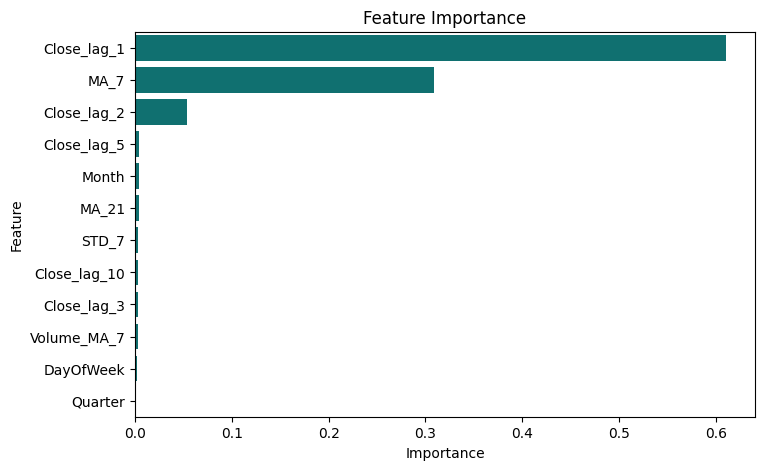

         Feature  Importance
0    Close_lag_1    0.609845
5           MA_7    0.308491
1    Close_lag_2    0.054176
3    Close_lag_5    0.004467
10         Month    0.004390
6          MA_21    0.003970
7          STD_7    0.002923
4   Close_lag_10    0.002886
2    Close_lag_3    0.002872
8    Volume_MA_7    0.002799
9      DayOfWeek    0.001681
11       Quarter    0.001500


In [ ]:
# Use this if XGBoost or Random Forest (tuned) won
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_best.feature_importances_   # swap for rf_best.feature_importances_ if RF won
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importances, color='teal')
plt.title('Feature Importance')
plt.show()

print(importances)

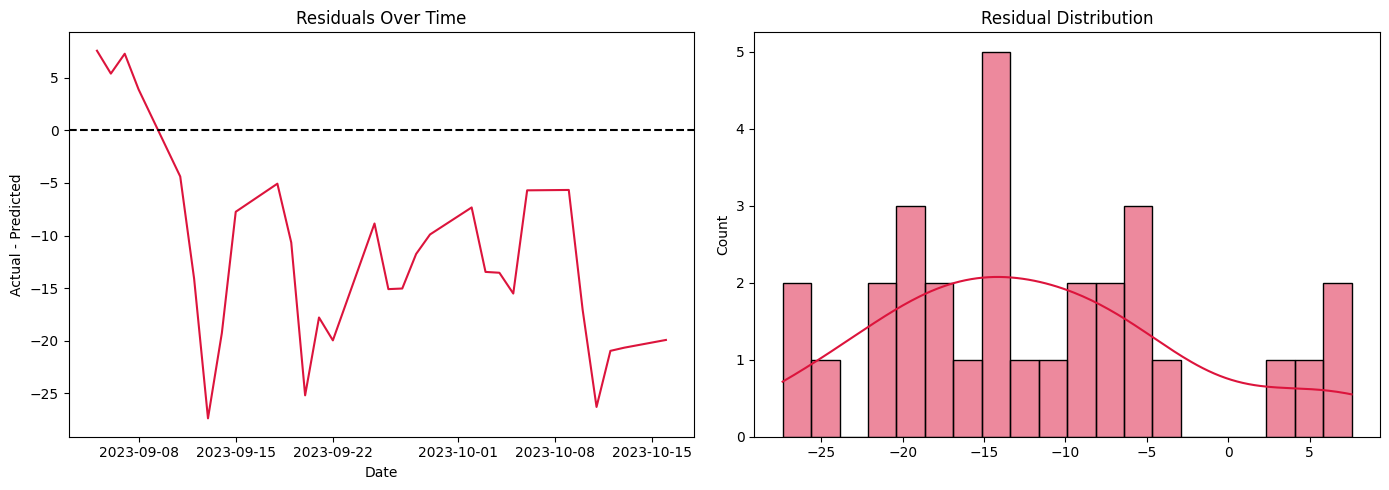

In [ ]:
# Swap xgb_best_pred for whichever model won
residuals = y_test.values - xgb_best_pred

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(test['Date'], residuals, color='crimson')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Actual - Predicted')

sns.histplot(residuals, bins=20, kde=True, color='crimson', ax=axes[1])
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

In [ ]:
last_known = df_model.iloc[-1:].copy()
future_preds = []

for i in range(30):
    X_future = last_known[feature_cols]
    pred = xgb_best.predict(X_future)[0]   # swap for your actual winning model
    future_preds.append(pred)

    new_row = last_known.copy()
    new_row['Close_lag_10'] = new_row['Close_lag_5']
    new_row['Close_lag_5'] = new_row['Close_lag_3']
    new_row['Close_lag_3'] = new_row['Close_lag_2']
    new_row['Close_lag_2'] = new_row['Close_lag_1']
    new_row['Close_lag_1'] = pred
    last_known = new_row

future_dates = pd.date_range(start=df['Date'].max() + pd.Timedelta(days=1), periods=30, freq='B')
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast_Close': future_preds})
print(forecast_df)

         Date  Forecast_Close
0  2023-10-17      380.747070
1  2023-10-18      387.386627
2  2023-10-19      389.485077
3  2023-10-20      389.684265
4  2023-10-23      391.372284
5  2023-10-24      391.790924
6  2023-10-25      391.790924
7  2023-10-26      391.790924
8  2023-10-27      391.790924
9  2023-10-30      391.790924
10 2023-10-31      391.790924
11 2023-11-01      391.790924
12 2023-11-02      391.790924
13 2023-11-03      391.790924
14 2023-11-06      391.790924
15 2023-11-07      391.790924
16 2023-11-08      391.790924
17 2023-11-09      391.790924
18 2023-11-10      391.790924
19 2023-11-13      391.790924
20 2023-11-14      391.790924
21 2023-11-15      391.790924
22 2023-11-16      391.790924
23 2023-11-17      391.790924
24 2023-11-20      391.790924
25 2023-11-21      391.790924
26 2023-11-22      391.790924
27 2023-11-23      391.790924
28 2023-11-24      391.790924
29 2023-11-27      391.790924


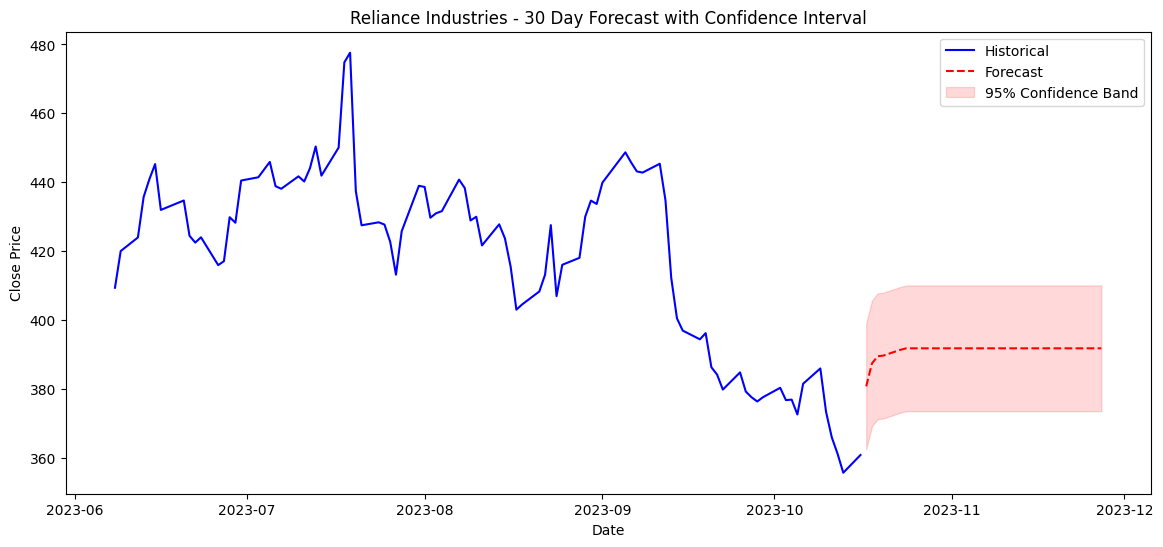

In [ ]:
residual_std = residuals.std()

forecast_df['Lower_Bound'] = forecast_df['Forecast_Close'] - 1.96 * residual_std
forecast_df['Upper_Bound'] = forecast_df['Forecast_Close'] + 1.96 * residual_std

plt.figure(figsize=(14,6))
plt.plot(df['Date'].tail(90), df['Close'].tail(90), label='Historical', color='blue')
plt.plot(forecast_df['Date'], forecast_df['Forecast_Close'], label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_df['Date'], forecast_df['Lower_Bound'], forecast_df['Upper_Bound'],
                  color='red', alpha=0.15, label='95% Confidence Band')
plt.title('Reliance Industries - 30 Day Forecast with Confidence Interval')
plt.xlabel('Date'); plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
forecast_df.to_csv('Reliance_30_Day_Forecast.csv', index=False)
print("Saved!")

Saved!


In [ ]:
import joblib

joblib.dump(xgb_best, 'reliance_forecast_model.pkl')
print("Model saved!")

Model saved!


In [ ]:
loaded_model = joblib.load('reliance_forecast_model.pkl')

test_pred = loaded_model.predict(X_test)
evaluate(y_test, test_pred, "Reloaded Model (sanity check)")

Reloaded Model (sanity check): RMSE=15.03  MAE=13.41  MAPE=3.49%


(np.float64(15.033877009968537),
 13.414881479817712,
 np.float64(3.485096624466015))

In [ ]:
joblib.dump(scaler, 'feature_scaler.pkl')

['feature_scaler.pkl']